In [2]:
from pathlib import Path

scan_dir = Path(r"Z:\exp\hkim\261004\images\test2x1")

In [3]:
import h5py
import hdf5plugin


detect_file = scan_dir / "test2x1_00201.h5"
with h5py.File(detect_file) as hf:
    print("key", list(hf.keys()))
    print(list(hf['entry'].keys()))
    print(list(hf['entry']['data']['data']))

key ['entry']
['data', 'instrument']
[array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), array([0, 0, 0, ..., 0, 0, 0], shape=(1028,), dtype=int32), ar

time 2026-10-05 10:05:16
409


C:\Users\9ccxsws\AppData\Local\Temp\ipykernel_26984\1531591687.py:24: RuntimeWarning: divide by zero encountered in log
  ax.imshow(np.log(image))
C:\Users\9ccxsws\AppData\Local\Temp\ipykernel_26984\1531591687.py:24: RuntimeWarning: invalid value encountered in log
  ax.imshow(np.log(image))


Text(0.5, 1.0, 'Z:\\exp\\hkim\\261004\\images\\IGOx4_3rd')

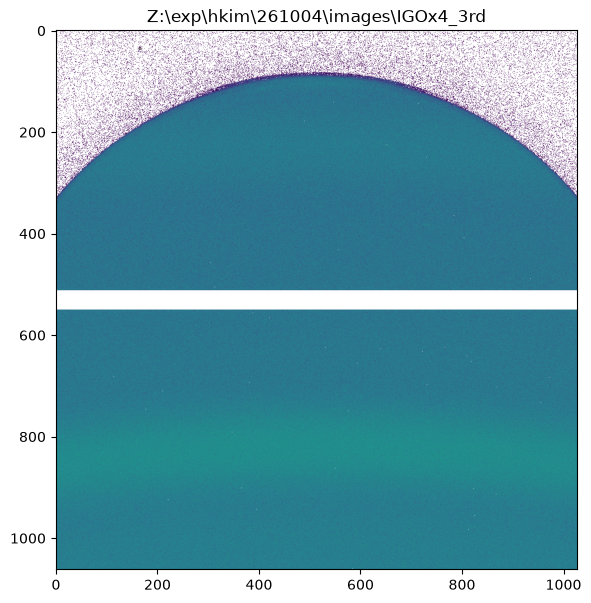

In [ ]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# temp_file = list(Path(r"D:\USER_DATA\hkim\261004\data\temperature\261004_9C_IGO_x4_2nd").iterdir())[-1]
temp_file = r"D:\USER_DATA\hkim\261004\data\temperature\261005_9C_IGO_x4_3rd\recipe_data_20261005_092228.csv"
scan_dir = Path(r"Z:\exp\hkim\261004\images\IGOx4_3rd")
detect_file = list(scan_dir.iterdir())[100]

df = pd.read_csv(
    temp_file,
    parse_dates=["Timestamp"]
)
with h5py.File(detect_file) as hf:
    sec = hf["entry"]["instrument"]["NDAttributes"]["NDArrayEpicsTSSec"][0]
    image = hf['entry']['data']['data'][()]

EPICS_OFFSET = 631152000       

t = datetime.fromtimestamp(sec + EPICS_OFFSET)
print("time", t)
closest_index = np.argmin(abs(df["Timestamp"] - t))
print(df.iloc[closest_index]["TC Temp PV [°C]"])
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(np.log(image))
ax.set_title(f"{detect_file.parent}")


In [ ]:


df = pd.read_csv(r'D:\USER_DATA\hkim\261004\data\temperature\manual_data_20261004_x1.csv',
                 parse_dates=["Timestamp"])

# 1) 특정 시각 이후
print(df)
print(df[df["Timestamp"] >= "2026-10-04 17:13"])

# # 2) 구간 (날짜 생략하고 시:분만 쓰고 싶을 때)
# d = df.set_index("Timestamp")
# print(d.between_time("17:00", "17:30"))

# # 3) 날짜+시각으로 구간 슬라이싱 (인덱스 정렬되어 있으면 가장 간단)
# print(d.loc["2026-10-04 16:00":"2026-10-04 16:30"])

                      Timestamp  Time [s]  TC Temp PV [°C]  TC Temp SV [°C]  \
0    2026-10-04 14:56:28.548976       9.0               26              NaN   
1    2026-10-04 14:56:29.543904      10.0               26              NaN   
2    2026-10-04 14:56:30.544414      11.0               26              NaN   
3    2026-10-04 14:56:31.560600      12.0               26              NaN   
4    2026-10-04 14:56:32.542835      13.0               26              NaN   
...                         ...       ...              ...              ...   
6747 2026-10-04 17:17:38.551693    5149.0               25             25.0   
6748 2026-10-04 17:17:39.556363    5150.0               25             25.0   
6749 2026-10-04 17:17:40.545741    5151.0               25             25.0   
6750 2026-10-04 17:17:41.548185    5152.0               25             25.0   
6751 2026-10-04 17:17:42.549638    5153.0               25             25.0   

      TC Hot [%]  TC Cool [%]  Chiller Temp PV [°C]

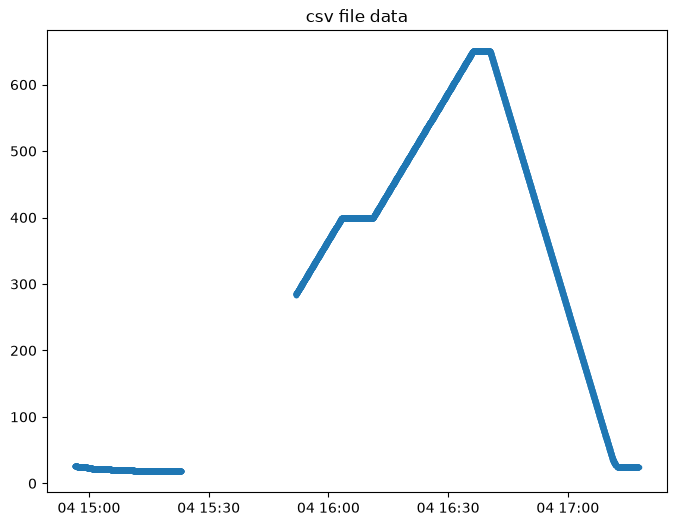

In [ ]:


fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_title("csv file data")
ax.plot(df["Timestamp"], df["TC Temp PV [°C]"], ".")

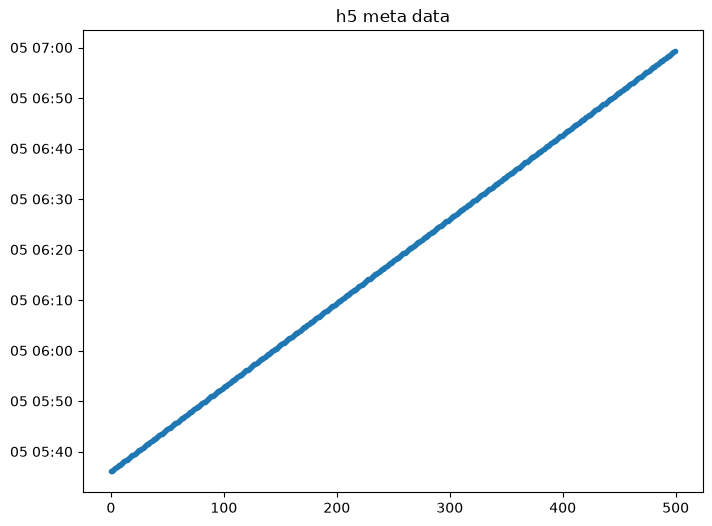

In [ ]:
from datetime import datetime, timezone, timedelta
import numpy as np

scan_dir = Path(r"Z:\exp\hkim\261004\images\IGOx8")

times = []

for detect_file in scan_dir.rglob("*.h5"):
    with h5py.File(detect_file) as hf:
        sec = hf["entry"]["instrument"]["NDAttributes"]["NDArrayEpicsTSSec"][0]

        EPICS_OFFSET = 631152000       

        t = datetime.fromtimestamp(sec + EPICS_OFFSET)
        times.append(t)

times = np.asarray(times)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_title("h5 meta data")
ax.plot(times, ".")